In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash

    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/mujoco_wrappers.py

    !pip -q install gymnasium[mujoco]
    
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

Starting virtual X frame buffer: Xvfb.


# Implementing Proximal Policy Optimization 


In this notebook you will be implementing Proximal Policy Optimization algorithm, 
scaled up version of which was used to train [OpenAI Five](https://openai.com/blog/openai-five/) 
to [win](https://openai.com/blog/how-to-train-your-openai-five/) against the
world champions in Dota 2.
You will be solving a continuous control environment on which it may be easier and faster 
to train an agent, however note that PPO here may not be the best algorithm as, for example,
Deep Deterministic Policy Gradient and Soft Actor Critic may be more suited 
for continuous control environments.

In [2]:
from tqdm import tqdm
from sklearn.metrics import r2_score

The overall structure of the code is similar to the one in the A2C optional homework, but don't worry if you haven't done it, it should be relatively easy to figure it out. 
First, we will create an instance of the environment. 
We will normalize the observations and rewards, but before that you will need a wrapper that will 
write summaries, mainly, the total reward during an episode. You can either use one for `TensorBoard` 
implemented in `atari_wrappers.py` file from the optional A2C homework, or implement your own. 

In [3]:
# !pip install "gymnasium[mujoco]"
%pip install gymnasium[mujoco]

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [4]:
import gymnasium as gym

env = gym.make("HalfCheetah-v4", render_mode="rgb_array")
print("observation space: ", env.observation_space, "\nobservations:", env.reset()[0])
print("action space: ", env.action_space, "\naction_sample: ", env.action_space.sample())

observation space:  Box(-inf, inf, (17,), float64) 
observations: [ 0.01004202 -0.00966791  0.04632013  0.07768523  0.02558229  0.03476895
 -0.00221017  0.07965043  0.11549069 -0.15286057 -0.0650691  -0.03279221
 -0.19946868  0.14970163  0.10801248  0.02343338  0.03305759]
action space:  Box(-1.0, 1.0, (6,), float32) 
action_sample:  [-0.7394861   0.6752584  -0.961479   -0.26559967  0.10959026 -0.68143   ]


/home/jupyter/.local/lib/python3.10/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


https://gymnasium.farama.org/environments/mujoco/half_cheetah/

![image.png](https://gymnasium.farama.org/_images/half_cheetah.png)

In [5]:
print(env.observation_space)
print(env.observation_space.shape)

Box(-inf, inf, (17,), float64)
(17,)


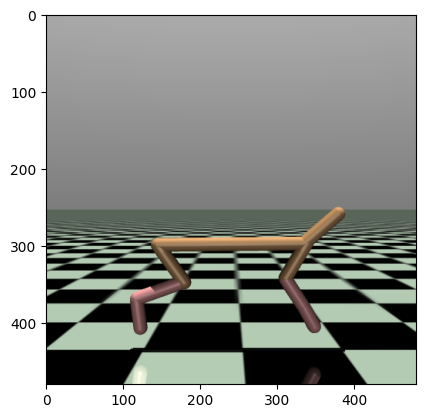

In [6]:
import matplotlib.pyplot as plt
plt.imshow(env.render())

In [7]:
import numpy as np

class Summaries(gym.Wrapper):
    """ Wrapper to write summaries. """
    def __init__(self, env):
        super().__init__(env)
        self.episode_counter = 0
        self.current_step_var = 0

        self.episode_rewards = [] # суммарная награда за эпизод
        self.episode_lens = [] # длина эпизда

        self.current_reward = 0
        self.current_len = 0

    def step(self, action):
        obs, rew, terminated, truncated, info = self.env.step(action)

        self.current_reward += rew
        self.current_len += 1
        self.current_step_var += 1

        if terminated or truncated:
            self.episode_rewards.append((self.current_step_var, self.current_reward))
            self.episode_lens.append((self.current_step_var, self.current_len))

        return obs, rew, terminated, truncated, info

    def reset(self, **kwargs):
        self.episode_counter += 1

        self.current_reward = 0
        self.current_len = 0

        return self.env.reset(**kwargs)

The normalization wrapper will subtract running mean from observations and rewards and divide 
the resulting quantities by the  running variances.

In [8]:
from mujoco_wrappers import Normalize

env = Normalize(Summaries(gym.make("HalfCheetah-v4", render_mode="rgb_array")));
env.reset(seed=0)

(array([-4.59893418e-04, -9.14117812e-04, -9.62360453e-04,  6.25252052e-04,
         8.22630939e-04,  2.13201754e-04,  4.58464641e-04,  8.72379386e-05,
        -1.25528645e-03, -6.22005395e-04,  4.13214942e-05, -2.26441131e-03,
        -2.18717453e-04, -1.23623025e-03, -7.30239312e-04, -5.43400491e-04,
        -3.16110471e-04]),
 {})

<!-- Next, you will need to define a model for training. We suggest that you use two separate networks: one for policy
and another for value function. Each network should be a 3-layer MLP with 64 hidden units, $\mathrm{tanh}$ 
activation function.

Our policy distribution is going to be multivariate normal with diagonal covariance. 
The network from above will predict the mean, and the covariance should be represented by a single 
(learned) vector of size 6 (corresponding to the dimensionality of the action space from above). Or you can also predict the variance using your model. You should take the exponent of that values to always have a non-negative quantity. 

Overall the model should return three things: predicted mean of the distribution, variance vector, 
value function.  -->

Затем вам необходимо определить модель для обучения. Мы рекомендуем использовать две отдельные сети: одну для стратегии (политики) и другую для функции ценности. Каждая сеть должна представлять собой трехслойный MLP (многослойный перцептрон) с 64 скрытыми узлами и функцией активации $\mathrm{tanh}$.

Наше распределение для стратегии будет многомерным нормальным с диагональной ковариационной матрицей. Указанная выше сеть будет предсказывать среднее значение (вектор средних), а ковариация должна быть представлена единым (обучаемым) вектором размерности 6 (что соответствует размерности пространства действий, указанного выше). Также вы можете предсказывать дисперсию с помощью своей модели. Вам следует брать экспоненту от этих значений, чтобы всегда получать неотрицательную величину.

В целом модель должна возвращать три величины: предсказанное среднее распределения, вектор дисперсий и значение функции ценности.

$a = (a_1, a_2, a_3, a_4, a_5, a_6)$ - одно действие, где $a_i \sim Normal(\mu, \sigma^2)$. 

Поскольку `diagonal covariance`, значит что все действия НЕ связаны и все элементы ВНЕ дианоли нулевые. 

$$\Sigma = diag \Big[ \sigma_1^2, \sigma_2^2, \sigma_3^2, \sigma_4^2, \sigma_5^2, \sigma_6^2 \Big]$$


In [9]:
# import tensorflow as tf
import torch

from torch import nn
from torch.nn import functional as F
import torch

class PolicyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.h = 64
        self.obs_dim = 17
        self.act_dim = 12
        

        self.policy_model = nn.Sequential(
            nn.Linear(in_features=self.obs_dim, out_features=self.h),
            nn.Tanh(), 
            nn.Linear(in_features=self.h, out_features=self.h),
            nn.Tanh(), 
            nn.Linear(in_features=self.h, out_features=self.act_dim),
        ) # < Create your model >

        self.value_model = nn.Sequential(
            nn.Linear(in_features=self.obs_dim, out_features=self.h),
            nn.Tanh(), 
            nn.Linear(in_features=self.h, out_features=self.h),
            nn.Tanh(), 
            nn.Linear(in_features=self.h, out_features=1),
        )  # < Create your model >

    def get_policy(self, x):
        # < insert your code here >
        actions = self.policy_model(x)
        means = actions[:, :6]
        var = actions[:, 6:]
        var = torch.exp(var) # >= 0
        return means, var

    def get_value(self, x):
        out = self.value_model(x.float())
        return out

    def forward(self, x):
        policy = self.get_policy(x)
        value = self.get_value(x)

        return policy, value

<!-- This model will be wrapped by a `Policy`. The policy can work in two modes, but in either case it is going to return dictionary with string-type keys.  -->
Эта модель будет обёрнута в `Policy`. Политика может работать в двух режимах, но в любом случае она будет возвращать словарь с ключами типа string.

<!-- The first mode is when the policy is used to sample actions for a trajectory which will later be used for training. In this case the flag `training` passed to `act` method is `False` and the method should return a `dict` with the following keys:  -->
Первый режим — это когда политика используется для выборки действий для траектории, которая затем будет использована для обучения. В этом случае флаг training, переданный в метод act, равен False, и метод должен возвращать словарь (`dict`) со следующими ключами:

<!-- 
* `"actions"`: actions to pass to the environment
* `"log_probs"`: log-probabilities of sampled actions
* `"values"`: value function $V^\pi(s)$ predictions. -->
- `"actions"`    : действия, которые передаются в среду
- `"log_probs"`  : логарифмы вероятностей выбранных действий
- `"values"`     : предсказания value-функции $V^\pi(s)$

<!-- We don't need to use the values under these keys for training, so all of them should be of type `np.ndarray`. -->
Значения под этими ключами не нужно использовать для обучения, поэтому все они должны быть типа np.ndarray.

<!-- When `training` is `True`, the model is training on a given batch of observations. In this case it should return a `dict` with the following keys -->
Когда training равно True, модель обучается на данном батче наблюдений. В этом случае она должна возвращать словарь (dict) со следующими ключами:

<!-- * `"distribution"`: an instance of multivariate normal distribution (`torch.distributions.MultivariateNormal` or `tf.distributions.MultivariateNormalDiag`)
* `"values"`: value function $V^\pi(s)$ prediction. -->
- `"distribution"`: экземпляр многомерного нормального распределения (`torch.distributions.MultivariateNormal` или `tf.distributions.MultivariateNormalDiag`)
- `"values"`: предсказание value-функции $V^\pi(s)$

<!-- The distinction about the modes comes into play depending on where the policy is used: if it is called from `EnvRunner`, the `training` flag is `False`, if it is called from `PPO`, the `training` flag is `True`. These classed will be described below.  -->
Различие между режимами имеет значение в зависимости от того, где используется политика: если она вызывается из `EnvRunner`, флаг `training` равен `False`; если вызывается из `PPO`, флаг `training` равен `True`. Эти классы будут описаны ниже.

In [10]:
from torch.distributions.normal import Normal
from torch.distributions.multivariate_normal import MultivariateNormal

class Policy:
    def __init__(self, model):
        self.model = model
    
    def act(self, inputs, training=False):
        # inputs = torch.tensor(inputs)
        inputs = torch.tensor(inputs, dtype=torch.float32)
        if inputs.ndim < 2:
            inputs = inputs.unsqueeze(0)
        inputs = inputs.cuda()
        
        batch_size = inputs.shape[0]

        # < insert your code here >
        means, var = self.model.get_policy(inputs)
        covar_matrix = torch.diag_embed(var) 

        normal_distr = MultivariateNormal(means, covariance_matrix=covar_matrix)

        actions = normal_distr.sample()
        log_probs = normal_distr.log_prob(actions)

        values = self.model.get_value(inputs)

        if not training:
            # action_numpy = actions[0].detach().cpu().numpy()
            # if action_numpy.shape == (1, 6):
            #     action_numpy = action_numpy[0]
            action_numpy = actions[0].detach().cpu().numpy().flatten()
            return {'actions': action_numpy, # actions.cpu().numpy().tolist(), 
                    'log_probs': log_probs[0].detach().cpu().numpy(),
                    'values': values[0].detach().cpu().numpy()}
        else:
            return {'distribution': normal_distr, 'values': values}

<!-- We will use `EnvRunner` to perform interactions with an environment with a policy for a fixed number of timesteps.  -->
Мы будем использовать `EnvRunner` для взаимодействия со средой с помощью политики в течение фиксированного числа шагов времени.

<!-- Calling `.get_next()` on a runner will return a trajectory &mdash; dictionary containing keys -->
Вызов метода `.get_next()` у runner вернёт траекторию — словарь, содержащий следующие ключи:

* `"observations"`— наблюдения
* `"rewards"` — награды
* `"resets"`— флаги сброса среды
* `"actions"`— действия
* all other keys that you defined in `Policy`,

<!-- under each of these keys there is a `np.ndarray` of specified length $T$ &mdash; the size of partial trajectory.  -->
Под каждым из этих ключей хранится np.ndarray длиной $T$ — размер частичной траектории.

<!-- Additionally, before returning a trajectory this runner can apply a list of transformations. Each transformation is simply a callable that should modify passed trajectory in-place. -->

Кроме того, перед возвратом траектории runner может применить список трансформаций. Каждая трансформация — это просто вызываемый объект (callable), который должен изменять переданную траекторию на месте (in-place).


In [11]:
class AsArray:
    """ 
    Converts lists of interactions to ndarray.
    """
    def __call__(self, trajectory):
        # Modify trajectory inplace. 
        for k, v in filter(lambda kv: kv[0] != "state", trajectory.items()):
            trajectory[k] = np.asarray(v)

In [12]:
""" RL env runner """
from collections import defaultdict

import numpy as np


class EnvRunner:
    """ Reinforcement learning runner in an environment with given policy """

    def __init__(self, env, policy, nsteps, transforms=None, step_var=None):
        self.env = env
        self.policy = policy
        self.nsteps = nsteps
        self.transforms = transforms or []
        self.step_var = step_var if step_var is not None else 0
        self.state = {"latest_observation": self.env.reset()[0]}

    @property
    def nenvs(self):
        """ Returns number of batched envs or `None` if env is not batched """
        return getattr(self.env.unwrapped, "nenvs", None)

    def reset(self, **kwargs):
        """ Resets env and runner states. """
        self.state["latest_observation"], info = self.env.reset(**kwargs)
        self.policy.reset()

    def get_next(self):
        """ Runs the agent in the environment.  """
        trajectory = defaultdict(list, {"actions": []})
        observations = []
        rewards = []
        resets = []
        self.state["env_steps"] = self.nsteps

        for i in range(self.nsteps):
            observations.append(self.state["latest_observation"])
            act = self.policy.act(self.state["latest_observation"])
            if "actions" not in act:
                raise ValueError("result of policy.act must contain 'actions' "
                                 f"but has keys {list(act.keys())}")
            for key, val in act.items():
                trajectory[key].append(val)

            obs, rew, terminated, truncated, _ = self.env.step(trajectory["actions"][-1])
            done = np.logical_or(terminated, truncated)
            self.state["latest_observation"] = obs
            rewards.append(rew)
            resets.append(done)
            self.step_var += self.nenvs or 1

            # Only reset if the env is not batched. Batched envs should
            # auto-reset.
            if not self.nenvs and np.all(done):
                self.state["env_steps"] = i + 1
                self.state["latest_observation"] = self.env.reset()[0]

        trajectory.update(
            observations=observations,
            rewards=rewards,
            resets=resets)
        trajectory["state"] = self.state

        for transform in self.transforms:
            transform(trajectory)
        return trajectory

In [13]:
import numpy as np

class DummyPolicy:
    def act(self, inputs, training=False):
        assert not training
        return {"actions": np.random.randn(6), "values": np.nan}

runner = EnvRunner(env, DummyPolicy(), 3,
                   transforms=[AsArray()])
trajectory = runner.get_next()

{k: v.shape for k, v in trajectory.items() if k != "state"}

{'actions': (3, 6),
 'values': (3,),
 'observations': (3, 17),
 'rewards': (3,),
 'resets': (3,)}

<!-- You will need to implement the following two transformations. 

The first is `GAE` that implements [Generalized Advantage Estimator](https://arxiv.org/abs/1506.02438).
In it you should add two keys to the trajectory: `"advantages"` and `"value_targets"`. In GAE the advantages
$A_t^{\mathrm{GAE}(\gamma,\lambda)}$ are essentially defined as the exponential 
moving average with parameter $\lambda$ of the regular advantages 
$\hat{A}^{(T)}(s_t) = \sum_{l=0}^{T-1-t} \gamma^l r_{t+l} + \gamma^{T} V^\pi(s_{T}) - V^\pi(s_t)$. 
The exact formula for the computation is the following

$$
A_{t}^{\mathrm{GAE}(\gamma,\lambda)} = \sum_{l=0}^{T-1-t} (\gamma\lambda)^l\delta_{t + l}^V, \, t \in [0, T)
$$
where $\delta_{t+l}^V = r_{t+l} + \gamma V^\pi(s_{t+l+1}) - V^\pi(s_{t+l})$. You can look at the 
derivation (formulas 11-16) in the paper. Don't forget to reset the summation on terminal
states as determined by the flags `trajectory["resets"]`. You can use `trajectory["values"]`
to get values of all observations except the most recent which is stored under 
 `trajectory["state"]["latest_observation"]`. For this observation you will need to call the policy 
 to get the value prediction.

Once you computed the advantages, you can get the targets for training the value function by adding 
back values:
$$
\hat{V}(s_{t+l}) = A_{t+l}^{\mathrm{GAE}(\gamma,\lambda)} + V(s_{t + l}),
$$
where $\hat{V}$ is a tensor of value targets that are used to train the value function.  -->

Вам нужно реализовать два преобразования.  

Первое — это `GAE`, которое реализует [Generalized Advantage Estimator](https://arxiv.org/abs/1506.02438).  
В нём необходимо добавить два ключа в траекторию: `"advantages"` и `"value_targets"`.  

В GAE преимущества $A_t^{\mathrm{GAE}(\gamma,\lambda)}$ по сути определяются как **экспоненциальное скользящее среднее** с параметром $\lambda$ для обычных преимуществ  

$$
\hat{A}^{(T)}(s_t) = \sum_{l=0}^{T-1-t} \gamma^l r_{t+l} + \gamma^{T} V^\pi(s_{T}) - V^\pi(s_t)
$$

Точная формула для вычисления:

$$
A_{t}^{\mathrm{GAE}(\gamma,\lambda)} = \sum_{l=0}^{T-1-t} (\gamma\lambda)^l \, \delta_{t+l}^V, \quad t \in [0, T)
$$

где

$$
\delta_{t+l}^V = r_{t+l} + \gamma V^\pi(s_{t+l+1}) - V^\pi(s_{t+l}).
$$

Вы можете посмотреть вывод формул (11–16) в статье. Не забудьте **сбрасывать сумму на терминальных состояниях**, определяемых флагами `trajectory["resets"]`.  

Можно использовать `trajectory["values"]` для получения значений функции ценности для всех наблюдений, **кроме последнего**, которое хранится в `trajectory["state"]["latest_observation"]`. Для этого наблюдения нужно вызвать политику, чтобы получить предсказание значения.  

---

После вычисления преимуществ можно получить **цели для обучения функции ценности**, добавив обратно значения:

$$
\hat{V}(s_{t+l}) = A_{t+l}^{\mathrm{GAE}(\gamma,\lambda)} + V(s_{t+l}),
$$

где $\hat{V}$ — это тензор целевых значений, используемый для обучения функции ценности.


In [14]:
keys=list(trajectory.keys())
keys

['actions', 'values', 'observations', 'rewards', 'resets', 'state']

In [15]:
print(trajectory['actions'])
# print(trajectory[keys[1]][0])
# print(trajectory[keys[2]])
# print(trajectory[keys[3]])
print(trajectory['resets'])
# print(trajectory[keys[5]][0])

[[-0.51262387  0.49858021  0.73215699  2.44012564  0.21512109  1.65282889]
 [ 1.83961042  1.11344828  1.35334813 -3.04736849 -1.09218691  0.64358276]
 [-2.95479907  0.37734096  1.11419254  0.09833285 -0.82212939 -0.80226047]]
[False False False]


In [16]:
print(len(trajectory["values"]), len(trajectory["rewards"]))

3 3


In [17]:
import os
class GAE:
    """ Generalized Advantage Estimator. """
    def __init__(self, policy, gamma=0.99, lambda_=0.95):
        self.policy = policy
        self.gamma = gamma
        self.lambda_ = lambda_
        
    def __call__(self, trajectory):

        gamma = self.gamma
        lambda_ = self.lambda_

        N = len(trajectory["observations"])
        Psi1 = np.zeros(N)
        PsiGAE = np.zeros(N)

        values = trajectory["values"]
        values = np.append(values, values[-1])

        rewards = trajectory["rewards"]
        resets = trajectory["resets"]

        for t in range(N):
                Psi1[t] = rewards[t] + (1 - resets[t]) * gamma * values[t+1] - values[t]

        PsiGAE[N-1] = Psi1[N-1]
        for t in range(N-2, -1, -1):
            PsiGAE[t] = Psi1[t] + lambda_ * gamma * PsiGAE[t+1] * (1 - resets[t])

        value_targets = np.array([PsiGAE[t] + values[t] for t in range(N)])

        trajectory["advantages"] = PsiGAE
        trajectory["value_targets"] = value_targets.reshape(-1, 1)
        

In [18]:
def test_gae():
    !curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/actions.npy
    !curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/log_probs.npy
    !curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/values.npy
    !curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/observations.npy
    !curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/rewards.npy
    !curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/resets.npy
    !curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/state.npy
    !curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/advantages.npy
    !curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/value_targets.npy
    !curl -O https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week09_policy_II/test_ppo/policy

    trajectory = {}
    for key in ['actions', 'log_probs', 'values', 'observations', 'rewards', 'resets']:
        trajectory[key] = np.load(f'{key}.npy', allow_pickle=True)
    trajectory['state'] = {"latest_observation": np.load('state.npy')}
    
    policy = torch.load(f'policy')
    gae_to_test = GAE(policy, gamma=0.99, lambda_=0.95)
    
    gae_to_test(trajectory)
    
    for key in ['advantages', 'value_targets']:
        # print(np.load(f'{key}.npy'))
        # print()
        # print(trajectory[key])
        # print()
        assert np.allclose(np.load(f'{key}.npy'), trajectory[key], atol=2e-2)
    
    print("It's all good!")
test_gae()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 98432  100 98432    0     0   547k      0 --:--:-- --:--:-- --:--:--  546k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8320  100  8320    0     0  52305      0 --:--:-- --:--:-- --:--:-- 52327
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8320  100  8320    0     0  29653      0 --:--:-- --:--:-- --:--:-- 29714
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  272k  100  272k    0     0   717k      0 --:--:-- --:--:-- --:--:--  719k
  % Total    % Received % Xferd  Average Speed   Tim

It's all good!


<!-- The main advantage of PPO over simpler policy based methods like A2C is that it is possible
to train on the same trajectory for multiple gradient steps. The following class wraps 
an `EnvRunner`. It should call the runner to get a trajectory, then return minibatches 
from it for a number of epochs, shuffling the data before each epoch. -->

Главное преимущество PPO по сравнению с более простыми методами на основе политики, такими как A2C, заключается в том, что можно обучаться на одной и той же траектории в течение нескольких шагов градиентного обновления. Следующий класс оборачивает `EnvRunner`: он должен вызвать runner, получить траекторию, а затем в течение нескольких эпох возвращать из неё мини-батчи, перемешивая данные перед каждой эпохой.

In [19]:
class TrajectorySampler:
    """ Samples minibatches from trajectory for a number of epochs. """
    def __init__(self, runner, num_epochs, num_minibatches, transforms=None):
        self.runner = runner
        self.num_epochs = num_epochs
        self.num_minibatches = num_minibatches
        self.transforms = transforms or []
        self.minibatch_count = 0
        self.epoch_count = 0
        self.trajectory = None

    def shuffle_trajectory(self):
        """ Shuffles all elements in trajectory.

        Should be called at the beginning of each epoch.
        """
        trajectory_len = self.trajectory["observations"].shape[0]

        permutation = np.random.permutation(trajectory_len)
        for key, value in self.trajectory.items():
            if key != 'state':
                self.trajectory[key] = value[permutation]

    def get_next(self):
        """ Returns next minibatch.  """
        if not self.trajectory:
            self.trajectory = self.runner.get_next()

        if self.minibatch_count == self.num_minibatches:
            self.shuffle_trajectory()
            self.minibatch_count = 0
            self.epoch_count += 1

        if self.epoch_count == self.num_epochs:
            self.trajectory = self.runner.get_next()

            self.shuffle_trajectory()
            self.minibatch_count = 0
            self.epoch_count = 0

        trajectory_len = self.trajectory["observations"].shape[0]

        batch_size = trajectory_len//self.num_minibatches

        minibatch = {}
        for key, value in self.trajectory.items():
            if key != 'state':
                minibatch[key] = value[self.minibatch_count*batch_size: (self.minibatch_count + 1)*batch_size]

        self.minibatch_count += 1

        for transform in self.transforms:
            transform(minibatch)

        return minibatch

<!-- A common trick to use with GAE is to normalize advantages, please implement the normalization. -->

Распространённый приём при использовании GAE — нормализовать advantages. Пожалуйста, реализуйте нормализацию.


In [20]:
class NormalizeAdvantages:
    """ Normalizes advantages to have zero mean and variance 1. """
    def __call__(self, trajectory):
        # < insert your code here >
        advantages = trajectory["advantages"]
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        trajectory["advantages"] = advantages

Finally, we can create our PPO runner. 

In [21]:
def make_ppo_runner(env, policy, num_runner_steps=2048,
                    gamma=0.99, lambda_=0.95, 
                    num_epochs=10, num_minibatches=32):
    """ Creates runner for PPO algorithm. """
    runner_transforms = [AsArray(),
                       GAE(policy, gamma=gamma, lambda_=lambda_)]
    runner = EnvRunner(env, policy, num_runner_steps, 
                     transforms=runner_transforms)

    sampler_transforms = [NormalizeAdvantages()]
    sampler = TrajectorySampler(runner, num_epochs=num_epochs, 
                              num_minibatches=num_minibatches,
                              transforms=sampler_transforms)
    return sampler

In the next cell you will need to implement Proximal Policy Optimization algorithm itself. The algorithm
modifies the typical policy gradient loss in the following way:

$$
J_{\pi}(s, a) = \frac{\pi_\theta(a|s)}{\pi_\theta^{\text{old}}(a|s)} \cdot A^{\mathrm{GAE}(\gamma,\lambda)}(s, a)
$$

$$
J_{\pi}^{\text{clipped}}(s, a) = \mathrm{clip}\left(
\frac{\pi_\theta(a|s)}{\pi_{\theta^{\text{old}}}(a|s)},
1 - \text{cliprange}, 1 + \text{cliprange}\right)\cdot A^{\mathrm{GAE(\gamma, \lambda)}}(s)\\
$$

$$
L_{\text{policy}} = -\frac{1}{T}\sum_{l=0}^{T-1}\min\left(J_\pi(s_{t + l}, a_{t + l}), J_{\pi}^{\text{clipped}}(s_{t + l}, a_{t + l})\right).
$$

The value loss is also modified:

$$
L_{V}^{\text{clipped}} = \frac{1}{T}\sum_{l=0}^{T-1} \max(l^{simple}(s_{t + l}), l^{clipped}(s_{t + l}))
$$
, where $l^{simple}$ is your standard critic loss
$$
l^{simple}(s_{t + l}) = [V_\theta(s_{t+l}) - G(s_{t + l})]^2
$$

and $l^{clipped}$ is a clipped version that limits large changes of the value function:
$$
l^{clipped}(s_{t + l}) = [
V_{\theta^{\text{old}}}(s_{t+l}) +
\text{clip}\left(
V_\theta(s_{t+l}) - V_{\theta^\text{old}}(s_{t+l}),
-\text{cliprange}, \text{cliprange}
\right) - G(s_{t + l})] ^ 2
$$

In [35]:
trajectory.keys()

dict_keys(['actions', 'log_probs', 'values', 'observations', 'rewards', 'resets', 'advantages', 'value_targets'])

In [52]:
class PPO:
    def __init__(self, policy, optimizer,
               cliprange=0.2,
               value_loss_coef=0.25,
               max_grad_norm=0.5):
        self.policy = policy
        self.optimizer = optimizer
        self.cliprange = cliprange
        self.value_loss_coef = value_loss_coef
        # Note that we don't need entropy regularization for this env.
        self.max_grad_norm = max_grad_norm

    def policy_loss(self, trajectory, act):
        """ Computes and returns policy loss on a given trajectory. """
        # < insert your code here >
        
        old_log_probs = torch.tensor(trajectory["log_probs"], dtype=torch.float32).cuda()
        
        new_dist = act["distribution"]
        actions_tensor = torch.tensor(trajectory["actions"], dtype=torch.float32).cuda()
        new_log_probs = new_dist.log_prob(actions_tensor)
        
        
        importance_ratio = torch.exp(new_log_probs - old_log_probs)
        importance_ratio_clip = torch.clamp(importance_ratio, 1 - self.cliprange, 1 + self.cliprange)
        L_Clip = - torch.mean(torch.min(importance_ratio, importance_ratio_clip))
        return L_Clip

    def value_loss(self, trajectory, act):
        """ Computes and returns value loss on a given trajectory. """
        # < insert your code here >
        value_targets = torch.tensor(trajectory["value_targets"], dtype=torch.float32).cuda()
        values = act["values"]
        L_MSE = torch.mean((values - value_targets)**2)
        return L_MSE

    def loss(self, trajectory):
        act = self.policy.act(trajectory["observations"], training=True)
        policy_loss = self.policy_loss(trajectory, act)
        value_loss = self.value_loss(trajectory, act)

        return policy_loss + self.value_loss_coef * value_loss

    def step(self, trajectory):
        """ Computes the loss function and performs a single gradient step. """
        self.optimizer.zero_grad()
        loss = self.loss(trajectory)

        loss.backward()

        grad_norm = nn.utils.clip_grad_norm_(self.policy.model.parameters(), self.max_grad_norm)

        self.optimizer.step()

Now everything is ready to do training. In one million of interactions it should be possible to 
achieve the total raw reward of about 1500. You should plot this quantity with respect to 
`runner.step_var` &mdash; the number of interactions with the environment. It is highly 
encouraged to also provide plots of the following quantities (these are useful for debugging as well):

* [Coefficient of Determination](https://en.wikipedia.org/wiki/Coefficient_of_determination) between 
value targets and value predictions
* Entropy of the policy $\pi$
* Value loss
* Policy loss
* Value targets
* Value predictions
* Gradient norm
* Advantages

For optimization it is suggested to use Adam optimizer with linearly annealing learning rate 
from 3e-4 to 0 and epsilon 1e-5.

In [53]:
model = PolicyModel()
model = model.cuda()

policy = Policy(model)

runner = make_ppo_runner(env, policy)

In [54]:
from IPython.display import clear_output
from matplotlib import pyplot as plt

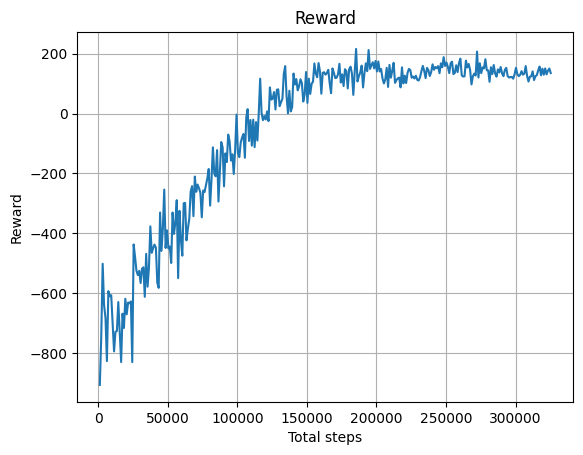

 19%|█▉        | 48429/250000 [12:13<50:51, 66.05it/s]  


KeyboardInterrupt: 

In [55]:
optimizer = torch.optim.Adam(policy.model.parameters(), lr = 3e-4, eps=1e-5)
epochs = 250000

lr_mult = lambda epoch: (1 - (epoch/epochs))
sched = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_mult)

ppo = PPO(policy, optimizer)

for epoch in tqdm(range(epochs)):
    trajectory = runner.get_next()

    if (epoch + 1) % 100 == 0:
        clear_output(True)
        rewards = np.array(env.env.episode_rewards)

        if rewards.size > 0:
            plt.plot(rewards[:, 0], rewards[:, 1], label = "episode rewards")
            plt.title("Reward")
            plt.xlabel("Total steps")
            plt.ylabel("Reward")
            plt.grid()
            plt.show()

    ppo.step(trajectory)
    sched.step()

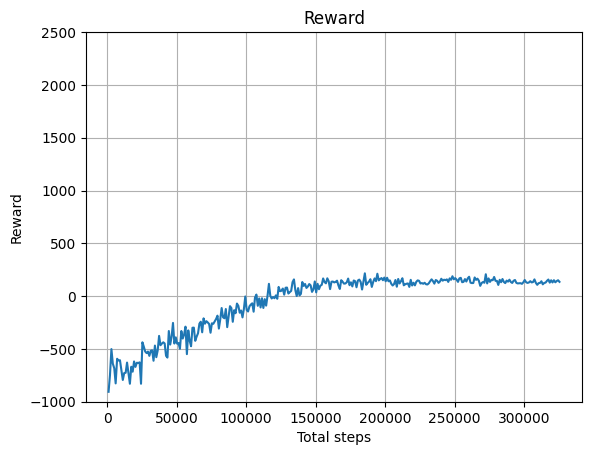

In [56]:
rewards = np.array(env.env.episode_rewards)

if rewards.size > 0:
    plt.plot(rewards[:, 0], rewards[:, 1], label = "episode rewards")
    plt.title("Reward")
    plt.xlabel("Total steps")
    plt.ylabel("Reward")
    plt.ylim(-1000, 2500)
    plt.grid()
    plt.show()

In [57]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import numpy as np

In [58]:
def record_video(policy, env_name="HalfCheetah-v4", video_folder="./videos", episode_length=1000):
    """
    Записывает видео работы политики в среде.
    
    Args:
        policy: обученная политика
        env_name: название среды
        video_folder: папка для сохранения видео
        episode_length: максимальная длина эпизода
    """
    # Создаем среду с записью видео
    env = gym.make(env_name, render_mode="rgb_array")
    env = RecordVideo(
        env, 
        video_folder=video_folder,
        episode_trigger=lambda x: True  # Записываем каждый эпизод
    )
    
    obs, info = env.reset()
    total_reward = 0
    
    for step in range(episode_length):
        # Получаем действие от политики
        act = policy.act(obs)
        action = act["actions"]
        
        # Шаг в среде
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        
        # Проверяем завершение эпизода
        done = terminated or truncated
        if done:
            break
    
    env.close()
    print(f"Episode reward: {total_reward}")
    print(f"Video saved to {video_folder}")
    return total_reward

# Использование:
# Создайте папку для видео
import os
os.makedirs("./videos", exist_ok=True)

# Запишите видео
reward = record_video(policy, video_folder="./videos")

/home/jupyter/.local/lib/python3.10/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/home/jupyter/.local/lib/python3.10/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/jupyter/work/resources/Practical RL/week09_trpo_ppo/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode reward: -3087.7991207134996
Video saved to ./videos
